In [155]:
print("reck98")
!(which python)
!(python --version)

reck98
/run/media/reck98/Others/Development/ML_NLP_DL/Ml-algorithms/.venv/bin/python
Python 3.12.12


In [156]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import math
import warnings
warnings.filterwarnings('ignore')
from pathlib import Path as FilePath

In [157]:
FILE_PATH = FilePath("./public/csv-files/heart.csv")

orginal_df = pd.read_csv(FILE_PATH)
df = orginal_df.copy()
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [158]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    str    
 2   ChestPainType   918 non-null    str    
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    str    
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    str    
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    str    
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), str(5)
memory usage: 86.2 KB


In [159]:
df['ChestPainType'].value_counts()

ChestPainType
ASY    496
NAP    203
ATA    173
TA      46
Name: count, dtype: int64

In [160]:
df['FastingBS'].value_counts()

FastingBS
0    704
1    214
Name: count, dtype: int64

In [161]:
df['RestingECG'].value_counts()

RestingECG
Normal    552
LVH       188
ST        178
Name: count, dtype: int64

In [162]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


<Axes: xlabel='HeartDisease'>

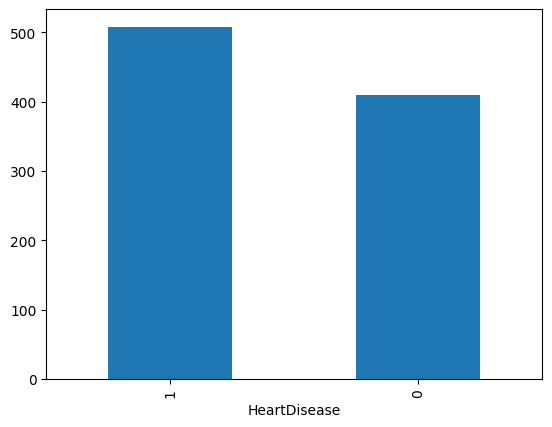

In [163]:
df['HeartDisease'].value_counts().plot(kind= 'bar')

In [164]:
df.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

In [165]:
numeric_columns = [feature for feature in df.columns if df[feature].dtype == 'float64' or df[feature].dtype == 'int64']
print(numeric_columns)
print(len(numeric_columns))
categorical_columns = [feature for feature in df.columns if df[feature].dtype == 'str']
print(categorical_columns)
print(len(categorical_columns))

print(len(df.columns))

['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak', 'HeartDisease']
7
['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']
5
12


In [166]:
# df['Oldpeak'].value_counts()

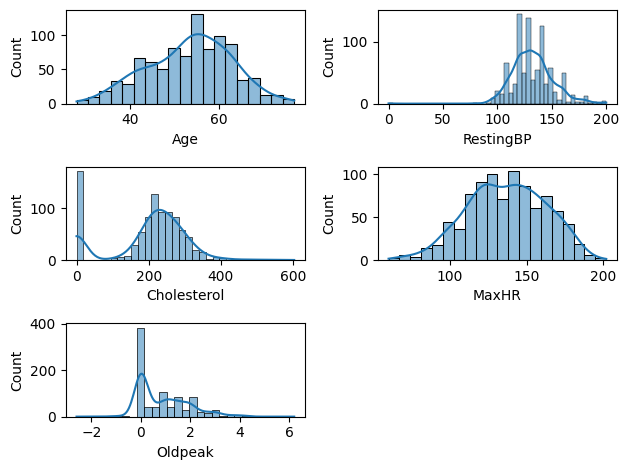

In [167]:
## Histogram for numerical
numeric_columns.remove('HeartDisease')

numeric_columns.remove('FastingBS')  ## This is a categorical column
categorical_columns.append('FastingBS')
i = 1
for col in numeric_columns:
    plt.subplot(3,2,i)
    sns.histplot(df[col], kde=True)
    i += 1

plt.tight_layout()
plt.show()


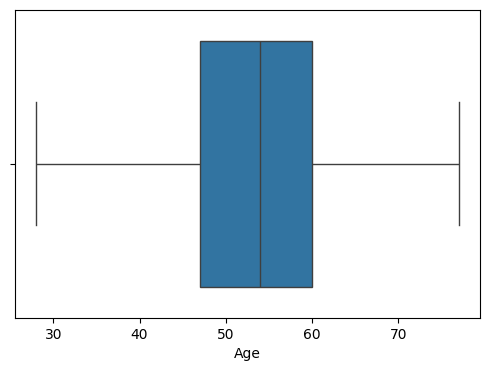

count    918.000000
mean      53.510893
std        9.432617
min       28.000000
25%       47.000000
50%       54.000000
75%       60.000000
max       77.000000
Name: Age, dtype: float64
 
 


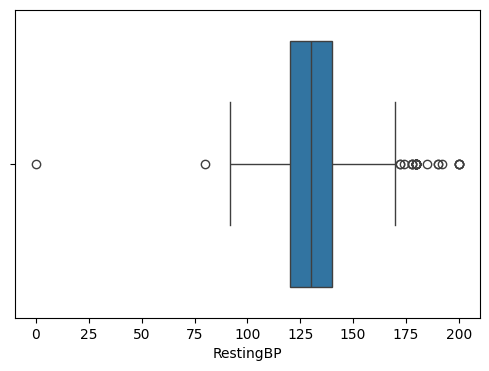

count    918.000000
mean     132.396514
std       18.514154
min        0.000000
25%      120.000000
50%      130.000000
75%      140.000000
max      200.000000
Name: RestingBP, dtype: float64
 
 


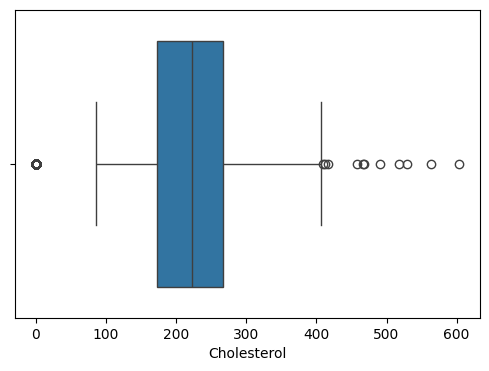

count    918.000000
mean     198.799564
std      109.384145
min        0.000000
25%      173.250000
50%      223.000000
75%      267.000000
max      603.000000
Name: Cholesterol, dtype: float64
 
 


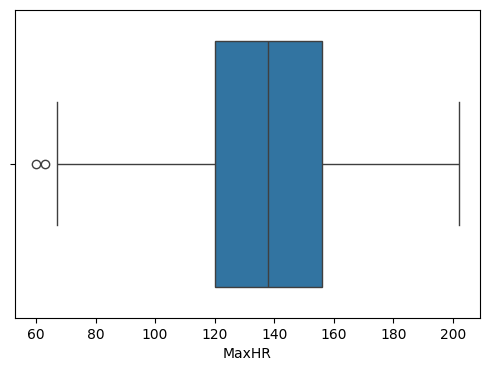

count    918.000000
mean     136.809368
std       25.460334
min       60.000000
25%      120.000000
50%      138.000000
75%      156.000000
max      202.000000
Name: MaxHR, dtype: float64
 
 


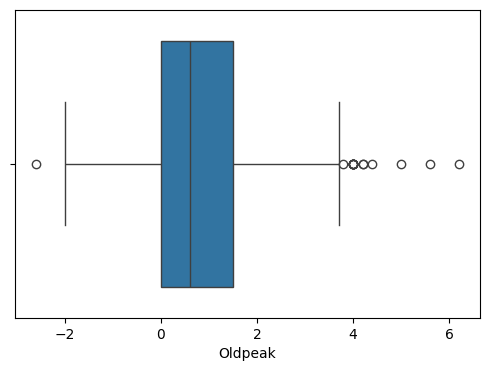

count    918.000000
mean       0.887364
std        1.066570
min       -2.600000
25%        0.000000
50%        0.600000
75%        1.500000
max        6.200000
Name: Oldpeak, dtype: float64
 
 


In [168]:
for col in numeric_columns:
    plt.figure(figsize=(6,4))
    sns.boxplot(x = df[col])
    plt.show()
    print(df[col].describe())
    print(" ")
    print(" ")

In [169]:
print(df['Cholesterol'].value_counts())
print(746 + 172)

Cholesterol
0      172
254     11
223     10
220     10
211      9
      ... 
353      1
278      1
157      1
176      1
131      1
Name: count, Length: 222, dtype: int64
918


In [170]:
ch_values = np.array([val for val in df['Cholesterol'] if val != 0])
print(len(ch_values))
ch_mean = np.mean(ch_values)
print(ch_mean)

746
244.6353887399464


In [171]:
df['Cholesterol'] = df['Cholesterol'].replace(0, ch_mean)
print(df['Cholesterol'].value_counts())

Cholesterol
244.635389    172
254.000000     11
223.000000     10
220.000000     10
211.000000      9
             ... 
353.000000      1
278.000000      1
157.000000      1
176.000000      1
131.000000      1
Name: count, Length: 222, dtype: int64


<Axes: xlabel='Cholesterol'>

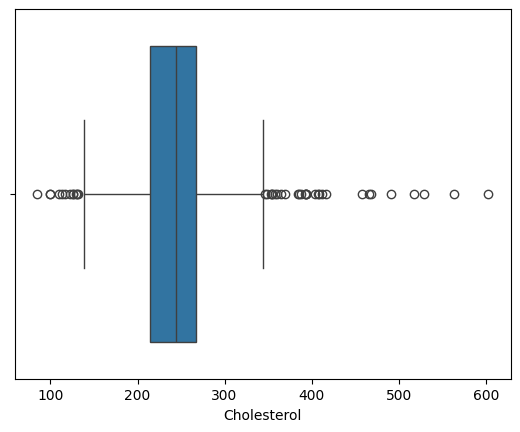

In [172]:
# sns.histplot(df['Cholesterol'], kde = True, bins=20)
sns.boxplot(x = df['Cholesterol'])

In [173]:
df['RestingBP'].value_counts()

RestingBP
120    132
130    118
140    107
110     58
150     55
      ... 
174      1
117      1
192      1
129      1
164      1
Name: count, Length: 67, dtype: int64

In [174]:
rbp = np.array([val for val in df['RestingBP'] if val != 0])
print(len(rbp))
rbp_mean = np.mean(rbp)
print(rbp_mean)
df['RestingBP'] = df['RestingBP'].replace(0, rbp_mean)
print(df['RestingBP'].value_counts())
# sns.boxplot(x = df['RestingBP'])



917
132.54089422028352
RestingBP
120.0    132
130.0    118
140.0    107
110.0     58
150.0     55
        ... 
174.0      1
117.0      1
192.0      1
129.0      1
164.0      1
Name: count, Length: 67, dtype: int64


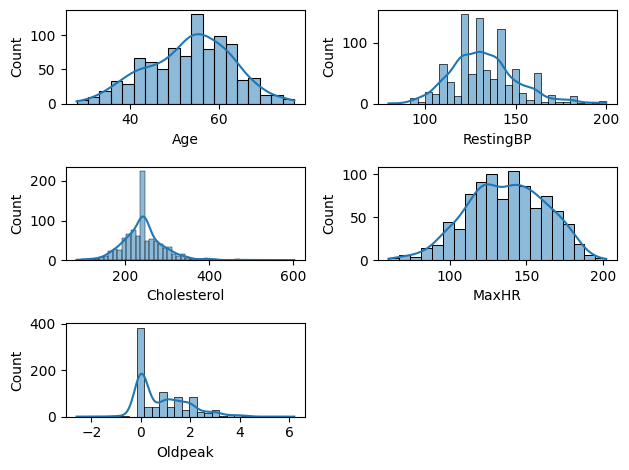

In [175]:
i = 1
for col in numeric_columns:
    plt.subplot(3,2,i)
    sns.histplot(df[col], kde=True)
    i += 1

plt.tight_layout()
plt.show()


In [176]:
print([val for val in df['Oldpeak'] if val < 0])

[-0.9, -2.6, -1.5, -0.1, -1.0, -1.1, -0.7, -0.8, -1.0, -0.5, -2.0, -0.5, -0.1]


In [177]:
len(categorical_columns)

6

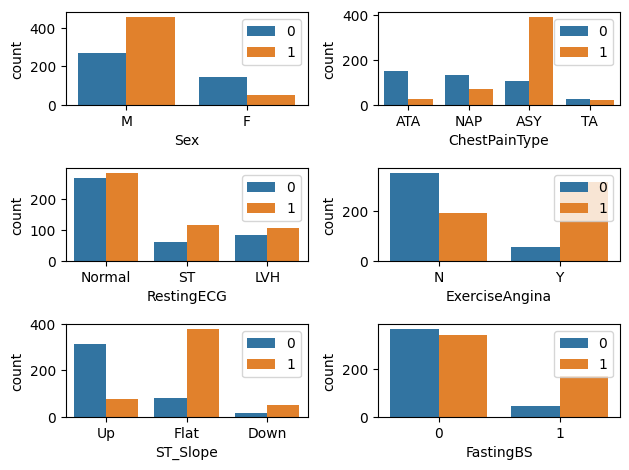

In [178]:
## 3, 2
i = 1
for col in categorical_columns:
    plt.subplot(3,2,i)
    sns.countplot(x = df[col], hue=df['HeartDisease'])
    plt.legend(loc = 'best')
    i += 1
    
plt.tight_layout()

<Axes: >

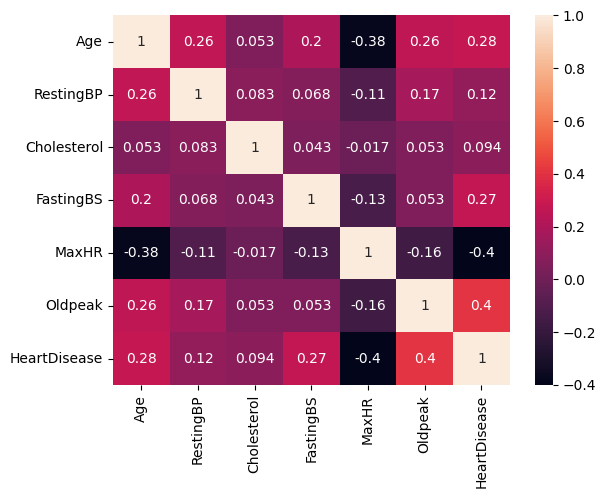

In [179]:
sns.heatmap(data=df.corr(numeric_only=True), annot=True)

In [180]:
df_encode = pd.get_dummies(df, drop_first=True)
df_encode =df_encode.astype(int)
df_encode.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,0,172,0,0,1,1,0,0,1,0,0,0,1
1,49,160,180,0,156,1,1,0,0,1,0,1,0,0,1,0
2,37,130,283,0,98,0,0,1,1,0,0,0,1,0,0,1
3,48,138,214,0,108,1,1,0,0,0,0,1,0,1,1,0
4,54,150,195,0,122,0,0,1,0,1,0,1,0,0,0,1


In [181]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df_encode[numeric_columns] = scaler.fit_transform(df_encode[numeric_columns])
df_encode.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,-1.433140,0.414885,0.834754,0,1.382928,-0.727592,0,1,1,0,0,1,0,0,0,1
1,-0.478484,1.527224,-1.210675,0,0.754157,0.282891,1,0,0,1,0,1,0,0,1,0
2,-1.751359,-0.141284,0.722161,0,-1.525138,-0.727592,0,1,1,0,0,0,1,0,0,1
3,-0.584556,0.303651,-0.572651,0,-1.132156,0.282891,1,0,0,0,0,1,0,1,1,0
4,0.051881,0.971054,-0.929194,0,-0.581981,-0.727592,0,1,0,1,0,1,0,0,0,1


In [182]:
final_df = df_encode.copy()

FILE_PATH = FilePath("./public/csv-files/heart_final.csv")
final_df.to_csv(FILE_PATH, index=False)